## **🤖  Step 4: Model Building — KNN & Naive Bayes**


## **4.2  Naive Bayes — Gaussian NB**


## import libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

## Load data

In [20]:
df = pd.read_csv('Main_clean_data.csv')

## Feature selection

In [21]:
x = df.drop('Churn',axis=1)
y = df['Churn']

## Train test split

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Handle imbalance data

In [23]:
smote = SMOTE()

In [24]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [25]:
print('Before smote:')
print(y_train.value_counts())

Before smote:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [26]:
print('After smote:')
print(y_train_smote.value_counts())

After smote:
Churn
0    4139
1    4139
Name: count, dtype: int64


## GaussianNB

In [27]:
gauss_nb = GaussianNB()

In [28]:
gauss_nb.fit(x_train_smote,y_train_smote)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [29]:
prd_gauss_nb = gauss_nb.predict(x_test)

## Accuracy score 

In [30]:
print(f'Accuracy score : {accuracy_score(y_test,prd_gauss_nb) * 100}')

Accuracy score : 70.61745919091554


## Naive Bayes — Gaussian NB confusion matrix

In [31]:
cm = confusion_matrix(y_test,prd_gauss_nb)

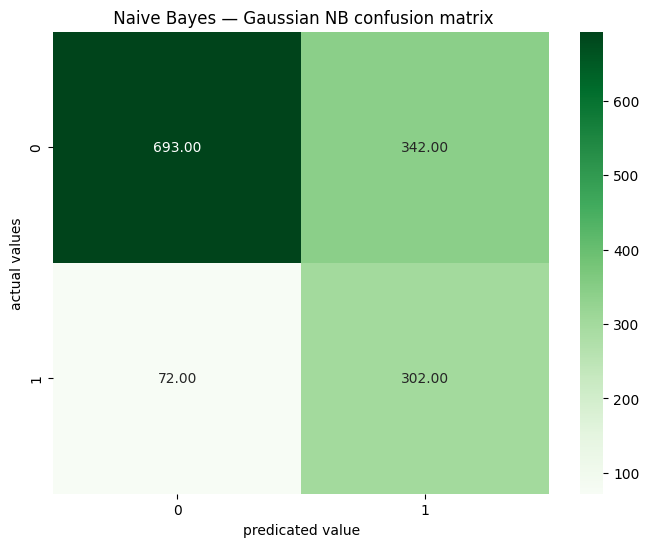

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt='.2f',cmap='Greens')
plt.xlabel('predicated value')
plt.ylabel('actual values')
plt.title(' Naive Bayes — Gaussian NB confusion matrix')
plt.show()

## classification report 


In [33]:
print(f'classification report :\n {classification_report(y_test,prd_gauss_nb)}')

classification report :
               precision    recall  f1-score   support

           0       0.91      0.67      0.77      1035
           1       0.47      0.81      0.59       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.71      0.72      1409



## Naive Bayes — Gaussian NB (ROC - AUC SCORE)

In [34]:
prd_prob = gauss_nb.predict_proba(x_test)[:,1]

score = roc_auc_score(y_test,prd_prob) * 100

print(f'  Naive Bayes — Gaussian NB (ROC - AUC SCORE) : {score:.4f}')

  Naive Bayes — Gaussian NB (ROC - AUC SCORE) : 81.1656


## Naive Bayes — Gaussian NB roc - auc

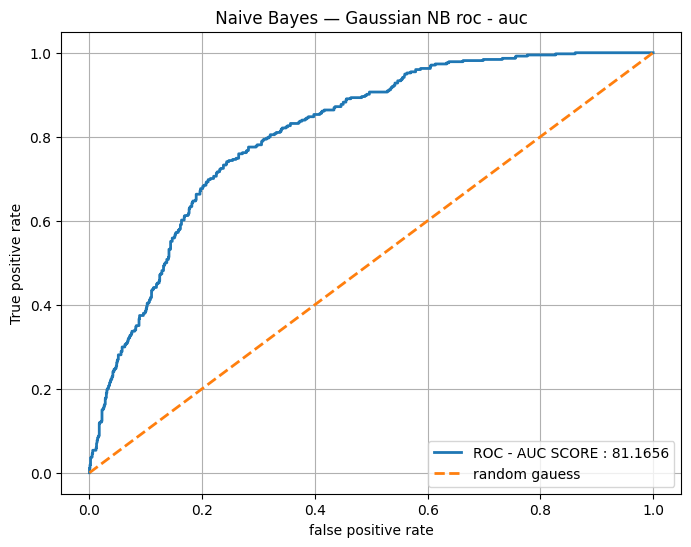

In [35]:
fpr,tpr,thresholds  = roc_curve(y_test,prd_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,linewidth=2,label = f'ROC - AUC SCORE : {score:.4f}')

plt.plot([0,1],[0,1],linestyle='--',linewidth=2,label = 'random gauess')

plt.xlabel('false positive rate')

plt.ylabel('True positive rate')

plt.title(' Naive Bayes — Gaussian NB roc - auc ')

plt.legend(loc = 'lower right')

plt.grid()
plt.show()

## Class prior probabilities

In [36]:
print(f'class prior probabilities : {gauss_nb.class_prior_}')

class prior probabilities : [0.5 0.5]


Naive Bayes assumes that all input features are independent of each other.
For the Telco Customer Churn dataset, this assumption is not completely true because several customer features are correlated. Even so, Gaussian Naive Bayes often provides a good baseline model.

# 📌 Gaussian Naive Bayes

## 📊 Performance Summary

| Metric | Gaussian Naive Bayes |
|---------|:--------------------:|
| Accuracy | **70.90%** |
| Precision | **47.00%** |
| Recall | **81.00%** |
| F1-Score | **0.6000** |
| ROC-AUC | **81.17%** |
| Class Prior Probability | **[0.5, 0.5]** |

## 📝 Conclusion

The Gaussian Naive Bayes classifier achieved an accuracy of **70.90%** with a high recall of **81%**, indicating that it successfully identified most customers who were likely to churn. The model produced a ROC-AUC score of **81.17%**, demonstrating good class separation capability. Although the precision is comparatively lower, this behavior is expected because Gaussian Naive Bayes assumes that all input features are statistically independent. The class prior probabilities of **[0.5, 0.5]** confirm that the training dataset became perfectly balanced after applying SMOTE. Overall, Gaussian Naive Bayes provides a simple, fast, and effective baseline model, particularly when detecting as many churn customers as possible is the primary objective.
